In [42]:
#_____Bibliotheken importieren_____
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [43]:
#_____Datensatz laden und Polteinstellungen_____
df = pd.read_csv('werkzeugbruch_training.csv')

  Datensatz: werkzeugbruch_training.csv

Shape      : 5,000 Zeilen × 4 Spalten
Bruchrate  : 5.24%  (262 Brüche / 5000 Samples)

── Erste 5 Zeilen ───────────────────────────────────
   depth_of_cut  feed_rate  tool_wear_min  tool_breakage
0          1.22      0.191           66.7              0
1          3.46      0.254          102.8              0
2          3.23      0.183           22.8              0
3          2.89      0.280           73.4              0
4          1.62      0.314           31.5              0

── Statistische Kennzahlen (Features) ───────────────
       depth_of_cut  feed_rate  tool_wear_min
count      5000.000   5000.000       5000.000
mean          2.242      0.278         58.950
std           1.181      0.156         34.687
min           0.500      0.050          0.000
25%           1.270      0.143         28.400
50%           2.040      0.251         58.900
75%           3.072      0.403         88.600
max           4.990      0.600        120.000

── Kla

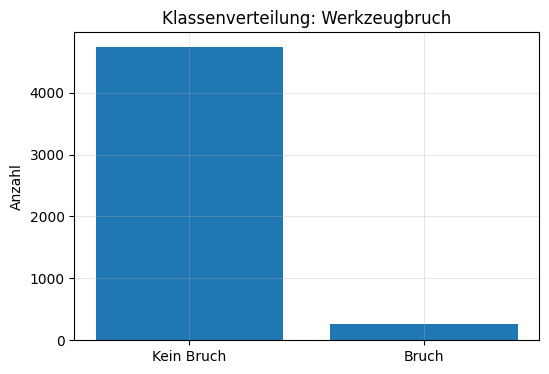

In [44]:
#_____Erste Datenanalyse_____
df = pd.read_csv('werkzeugbruch_training.csv')

print("=" * 55)
print("  Datensatz: werkzeugbruch_training.csv")
print("=" * 55)
print(f"\nShape      : {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"Bruchrate  : {df['tool_breakage'].mean():.2%}  "
      f"({df['tool_breakage'].sum()} Brüche / {len(df)} Samples)\n")

print("── Erste 5 Zeilen ───────────────────────────────────")
print(df.head().to_string(index=True))

print("\n── Statistische Kennzahlen (Features) ───────────────")
print(df[['depth_of_cut', 'feed_rate', 'tool_wear_min']].describe().round(3).to_string())

print("\n── Klassenverteilung ─────────────────────────────────")
vc = df['tool_breakage'].value_counts()
print(f"  Klasse 0 (kein Bruch): {vc[0]:5,}  ({vc[0]/len(df):.1%})")
print(f"  Klasse 1 (Bruch)     : {vc[1]:5,}  ({vc[1]/len(df):.1%})")

plt.figure(figsize=(6,4))
plt.bar(['Kein Bruch', 'Bruch'], [vc[0], vc[1]])
plt.ylabel('Anzahl')
plt.title('Klassenverteilung: Werkzeugbruch')
plt.show()

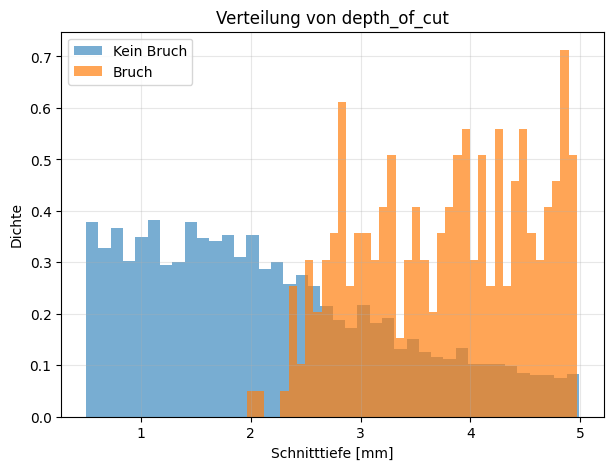

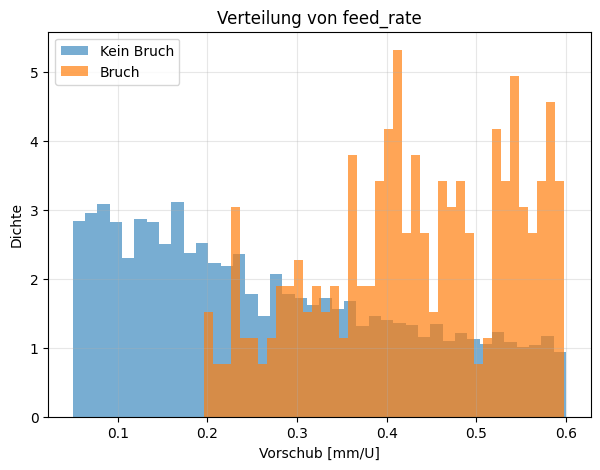

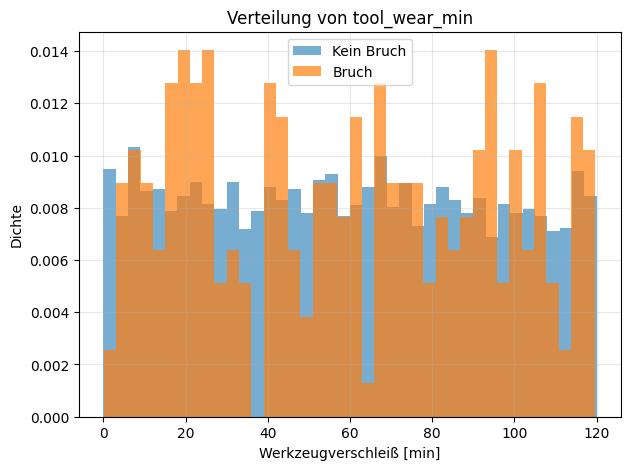

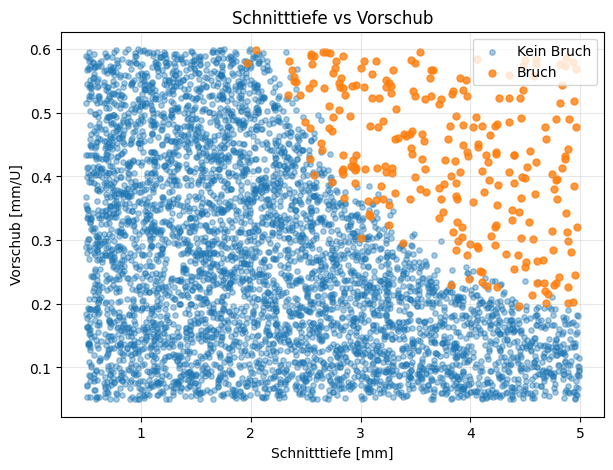

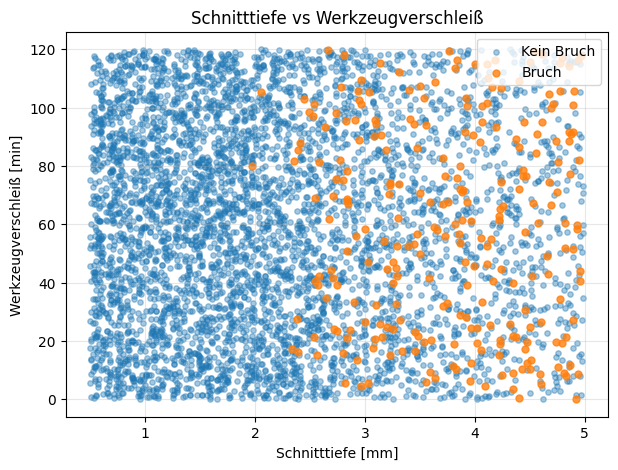

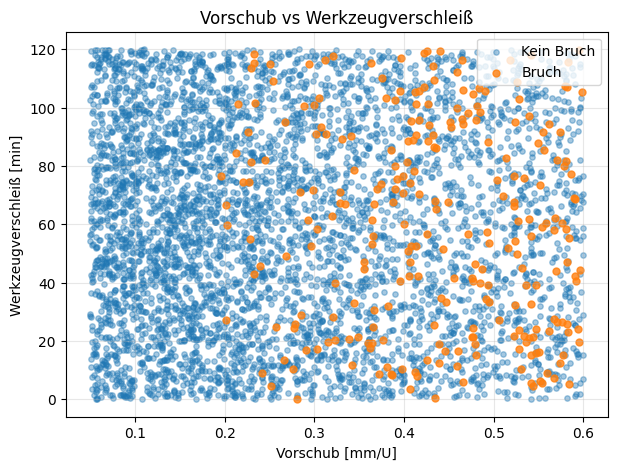

In [45]:
# ── Feature-Verteilungen nach Klasse ──────────────────────────────────────────
features = ['depth_of_cut', 'feed_rate', 'tool_wear_min']

# feature_labels ist ein Dictionary, das die technischen Namen der Features (z.B. 'depth_of_cut') den lesbaren Bezeichnungen (z.B. 'Schnitttiefe [mm]') zuordnet, die in den Plots verwendet werden.
feature_labels = {
'depth_of_cut': 'Schnitttiefe [mm]',
'feed_rate': 'Vorschub [mm/U]',
'tool_wear_min': 'Werkzeugverschleiß [min]'
}

# Die Schleife läudt über jedes Feature in der Liste 'features' und erstellt für jedes Feature ein Histogramm. es Zeigt die Verteilung des Features für die beiden Klassen (kein Bruch vs. Bruch). Die Daten werden dabei in zwei Gruppen aufgeteilt: df_kein_bruch enthält die Zeilen ohne Bruch (tool_breakage == 0) und df_bruch enthält die Zeilen mit Bruch (tool_breakage == 1). 
for feature in features:
    
    # 7,5 setht für die Größe der Abbildung in Zoll (Breite x Höhe)
    plt.figure(figsize=(7,5))

    df_kein_bruch = df[df['tool_breakage'] == 0]
    df_bruch = df[df['tool_breakage'] == 1]

    plt.hist(df_kein_bruch[feature], bins=40, alpha=0.6, label='Kein Bruch', density=True)
    plt.hist(df_bruch[feature], bins=40, alpha=0.7, label='Bruch', density=True)

    plt.xlabel(feature_labels[feature])
    plt.ylabel('Dichte')
    plt.title(f'Verteilung von {feature}')
    plt.legend()
    plt.show()


# ── plots der Feature-Kombinationen ────────────────────────────────────
plt.figure(figsize=(7,5))
# df[df['tool_breakage']==0] filtert die Zeilen, bei denen kein Bruch vorliegt, und df[df['tool_breakage']==1] filtert die Zeilen mit Bruch.
plt.scatter(df[df['tool_breakage']==0]['depth_of_cut'], df[df['tool_breakage']==0]['feed_rate'], s=15, alpha=0.4, label='Kein Bruch')
plt.scatter(df[df['tool_breakage']==1]['depth_of_cut'], df[df['tool_breakage']==1]['feed_rate'], s=25, alpha=0.8, label='Bruch')
plt.xlabel('Schnitttiefe [mm]')
plt.ylabel('Vorschub [mm/U]')
plt.title('Schnitttiefe vs Vorschub')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df[df['tool_breakage']==0]['depth_of_cut'], df[df['tool_breakage']==0]['tool_wear_min'], s=15, alpha=0.4, label='Kein Bruch')
plt.scatter(df[df['tool_breakage']==1]['depth_of_cut'], df[df['tool_breakage']==1]['tool_wear_min'], s=25, alpha=0.8, label='Bruch')
plt.xlabel('Schnitttiefe [mm]')
plt.ylabel('Werkzeugverschleiß [min]')
plt.title('Schnitttiefe vs Werkzeugverschleiß')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df[df['tool_breakage']==0]['feed_rate'], df[df['tool_breakage']==0]['tool_wear_min'], s=15, alpha=0.4, label='Kein Bruch')
plt.scatter(df[df['tool_breakage']==1]['feed_rate'], df[df['tool_breakage']==1]['tool_wear_min'], s=25, alpha=0.8, label='Bruch')
plt.xlabel('Vorschub [mm/U]')
plt.ylabel('Werkzeugverschleiß [min]')
plt.title('Vorschub vs Werkzeugverschleiß')
plt.legend()
plt.show()